In [50]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix


import warnings
warnings.filterwarnings('ignore')

In [51]:
df = pd.read_csv('ushape.csv')
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


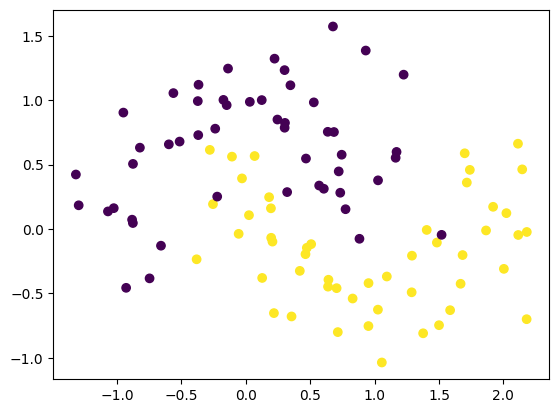

In [52]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values


plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [53]:
reg = LogisticRegression()
reg.fit(X, y)

np.mean(cross_val_score(reg, X, y, scoring='accuracy', cv=10))

np.float64(0.8300000000000001)

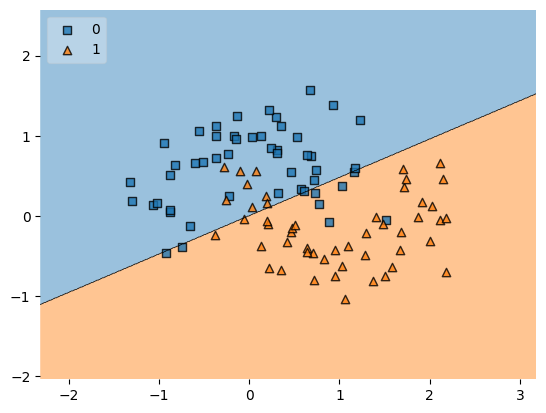

In [54]:

from mlxtend.plotting import plot_decision_regions      # this import is used to separate the classes region wise
plot_decision_regions(X, y.astype('int'), reg, legend=2)
plt.show()

In [ ]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_trf = poly.fit_transform(X)


reg1 = LogisticRegression()
np.mean(cross_val_score(reg1, X_trf, y, scoring='accuracy', cv=10))     # as you can see, as we used polynomial features, the accuracy has increased by 7 %


np.float64(0.9)

In [56]:
def plot_decision_boundary(X, y, degree=1):
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)

    clf = LogisticRegression()
    clf.fit(X_trf, y)

    accuracy = np.mean(cross_val_score(clf, X_trf, y, scoring='accuracy', cv=10))

    a = np.arange(start=X[:, 0].min()-1, stop=X[:, 0].max()+1, step=0.01)
    b = np.arange(start=X[:, 1].min()-1, stop=X[:, 1].max()+1, step=0.01)

    XX, YY = np.meshgrid(a, b)

    input_array = np.array([XX.ravel(), YY.ravel()]).T
    labels = clf.predict(poly.transform(input_array))

    plt.contourf(XX, YY, labels.reshape(XX.shape), alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree, np.round(accuracy, 4)))
    plt.show()

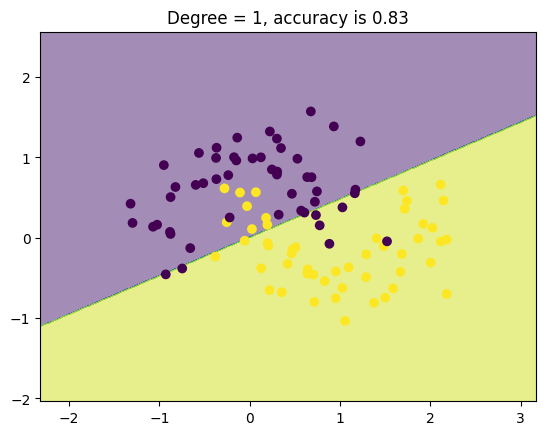

In [57]:
plot_decision_boundary(X, y)

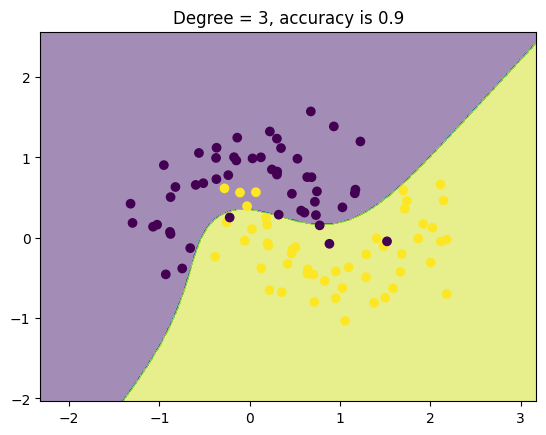

In [58]:
plot_decision_boundary(X, y, degree=3)      # the more you keep increasing the degree, the more you will be close to overfitting

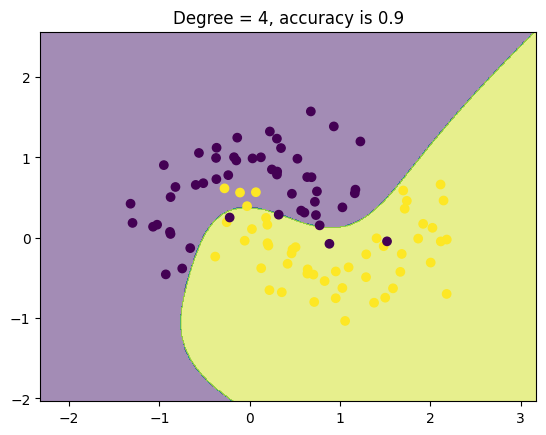

In [59]:
plot_decision_boundary(X, y, degree=4)

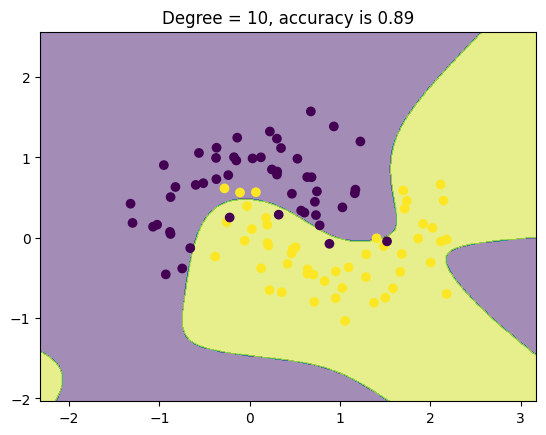

In [60]:
plot_decision_boundary(X, y, degree=10)